# One-dimensional Regression problem with NN
*Goal*: fit a scalar real-valued funciton
$ f: D \subset \mathbb{R} \rightarrow \mathbb{R}$

Import dependencies

In [5]:
import sys; sys.path.append('../src/playground_jax')
from time import time

import jax
from jax import numpy as jnp
from jaxtyping import Array, PyTree
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

from models_equinox import MLP

Define *target function*. For instance, $x \mapsto f(x) = \sqrt{|x|}$

In [2]:
def f_fn(x: Array):
    return jnp.sqrt(jnp.abs(x))
    #return jnp.pow(x, 2)
    #return jnp.exp(x)
    #return jnp.sin(jnp.pi *x)

Generate training data
   
A) Use the discretized grid as the input

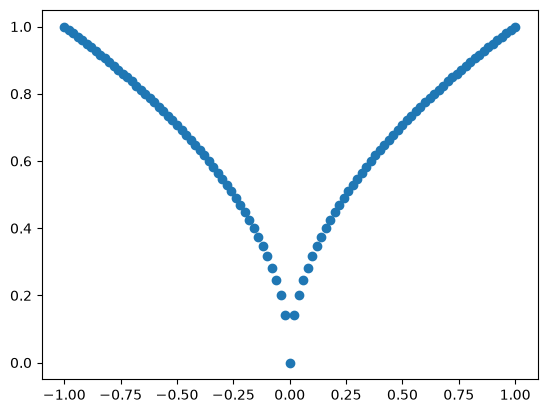

In [3]:
N = 101
x_train = jnp.linspace(-1, 1, N).reshape(-1, 1)
y_train = f_fn(x_train)
plt.scatter(x_train, y_train);

B) Sample from the Gaussian distribution as the input

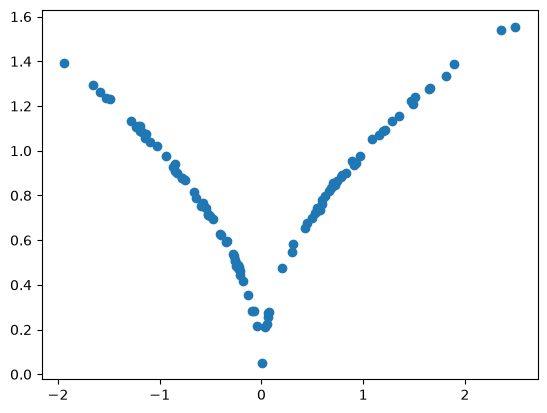

In [48]:
# sample K random points from the Gaussian distribution as input
K = 100
x_train = np.random.normal(size=K).reshape(-1, 1)

# sample Gaussian noise with mean=0 and std=0.05
noise = np.random.normal(loc=0, scale=0.01, size=K).reshape(-1, 1)

# generate target points y = f(x) + eps, where eps is the Gaussian noise 
y_train = f_fn(x_train) + noise

# show results
plt.scatter(x_train, y_train);

Build a model

In [6]:
# set a random key
key = jax.random.PRNGKey(1)

# define dimensions of the input, hidden, and output layers
d_in, d_hiddens, d_out = 1, [32, 16, 8], 1

#model = Linear(d_in, d_out, key=key)
model = MLP(d_in, d_out, d_hiddens,
            activation=jax.nn.tanh, final_activation=lambda x: x, key=key)

Define evaluation function to handle batch input

In [8]:
def evaluate(model: MLP, x: Array):
    y_pred = jax.vmap(model, in_axes=0, out_axes=0)(x)
    return y_pred

y_init = evaluate(model, x_train)

Define MSE loss

In [9]:
def loss_fn(model: MLP, x: Array, y: Array) -> Array:
    '''
    Computes the mean square error loss (mse)
    '''
    y_pred = evaluate(model, x)
    return jnp.mean((y_pred - y) ** 2)

Choose optimizer

In [10]:
lr = 1e-2
opt = optax.adam(learning_rate=lr)
opt_state = opt.init(eqx.filter(model, eqx.is_array))

Define train step function method.

In [11]:
@eqx.filter_jit
def train_step(model: MLP, opt_state: PyTree, x: Array, y: Array):
    
    # evaluate loss and compute gradients
    loss_value, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)

    # compute the updates following the chosen optimizer's rule
    updates, opt_state = opt.update(grads, opt_state)

    # update parameters
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss_value

Train

In [12]:
n_iter = int(1e4)
log_period_iter = int(1e3)
for i in range(n_iter):
    t0 = time()
    model, opt_state, loss_value = train_step(model, opt_state, x_train, y_train)
    t1 = time()
    if i % log_period_iter  == 0: 
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss_value, t1-t0))

it: 0, loss: 1.265e+00, time: 0.2359s
it: 1000, loss: 1.732e-04, time: 0.0002s
it: 2000, loss: 7.515e-05, time: 0.0002s
it: 3000, loss: 4.025e-05, time: 0.0003s
it: 4000, loss: 1.072e-05, time: 0.0002s
it: 5000, loss: 2.730e-06, time: 0.0002s
it: 6000, loss: 1.344e-04, time: 0.0002s
it: 7000, loss: 1.938e-06, time: 0.0002s
it: 8000, loss: 1.894e-06, time: 0.0002s
it: 9000, loss: 1.558e-06, time: 0.0002s


Evaluate results

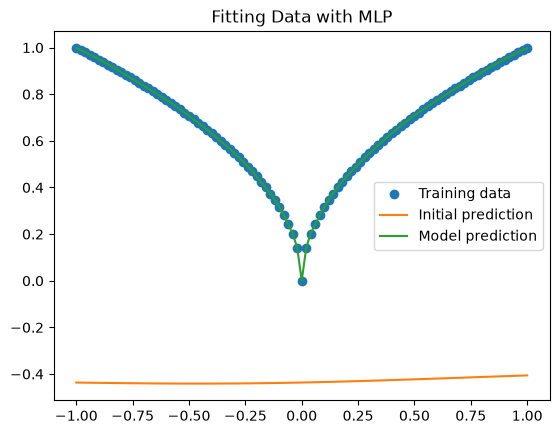

In [13]:
y_pred = evaluate(model, x_train)
fig, ax = plt.subplots()
ax.set_title('Fitting Data with MLP');
ax.scatter(x_train, y_train, c='tab:blue', label='Training data')
ax.plot(x_train, y_init, c='tab:orange', label='Initial prediction')
ax.plot(x_train, y_pred, c='tab:green', label='Model prediction')
ax.legend();

Computes the _r2 score_

In [14]:
r2 = round(float(r2_score(y_train, y_pred)), 4)
print("R^2 Score:", r2)

R^2 Score: 1.0
